# OIBSIP Data Science Task 3 — Car Price Prediction

## Objective

Predict the selling price of used cars using machine learning regression.

This notebook covers data loading, cleaning, EDA, feature engineering,
preprocessing, model training, evaluation, comparison, findings, and conclusion.

**Dataset file:** `car_data.csv`

## 1. Import Libraries

Import the libraries needed for analysis, visualization, and machine learning.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [9]:
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

The car dataset is loaded using Pandas.

In [13]:
import pandas as pd

df = pd.read_csv(r"C:\Users\rrama_t5uaug6\Downloads\car data.csv")

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3. Dataset Overview

The dataset is inspected to understand its size, column names,
data types, and overall structure.

In [15]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(301, 9)

Column Names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


## 4. First and Last Rows

The first and last records are displayed to verify that the dataset
has been loaded correctly.

In [17]:
display(df.head())
display(df.tail())

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


## 5. Clean Column Names

Leading and trailing spaces are removed from column names to make
the dataset easier to work with.

In [19]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


## 6. Check for Missing Values

Missing values are checked before performing further analysis.

In [20]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:")
print(missing_values.sum())

Missing values in each column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Total missing values:
0


## 7. Check for Duplicate Rows

Duplicate records are checked because repeated observations can
affect the analysis and machine learning model.

In [21]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed.")

Number of duplicate rows: 2
Duplicate rows removed.


## 8. Descriptive Statistics

Descriptive statistics are used to understand the numerical
variables in the dataset.

In [22]:
df.describe(include="all")

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,299,299.000000,299.000000,299.000000,299.000000,299,299,299,299.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,193,260,NaN
mean,NaN,2013.615385,4.589632,7.541037,36916.752508,NaN,NaN,NaN,0.043478
std,NaN,2.896868,4.984240,8.567887,39015.170352,NaN,NaN,NaN,0.248720
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.850000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.510000,6.100000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.840000,48883.500000,NaN,NaN,NaN,0.000000


## 9. Categorical Variable Analysis

The unique values of important categorical variables are inspected
before they are encoded for machine learning.

In [23]:
for column in ["Fuel_Type", "Seller_Type", "Transmission", "Owner"]:
    
    if column in df.columns:
        print(f"\n{column}:")
        print(df[column].value_counts())


Fuel_Type:
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Seller_Type:
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

Owner:
Owner
0    288
1     10
3      1
Name: count, dtype: int64


## 10. Distribution of Selling Price

The distribution of selling prices is visualized to understand
how prices are spread across the dataset.

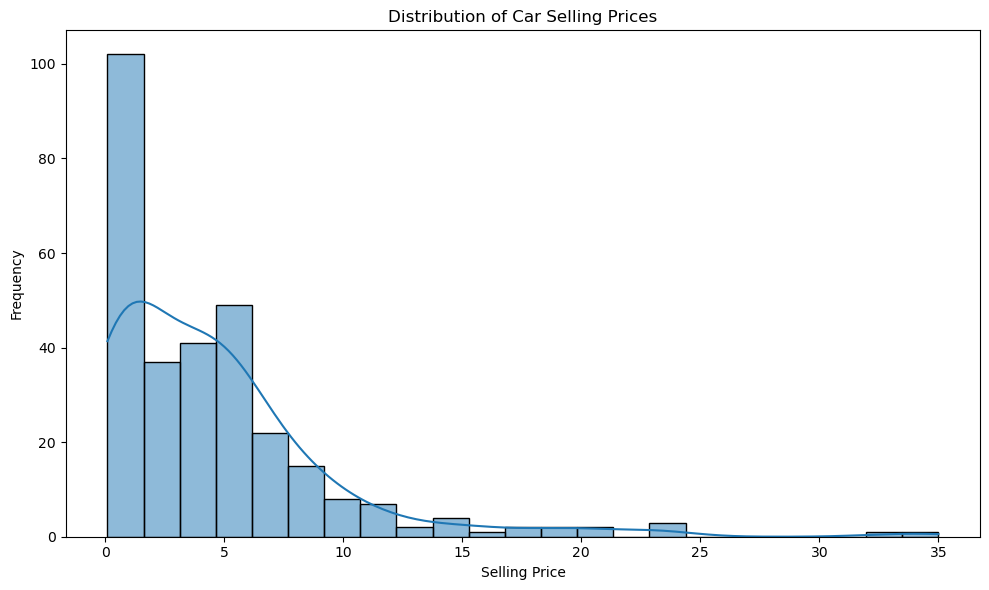

In [24]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Selling_Price"],
    kde=True
)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation

The graph shows the distribution of selling prices across the
cars in the dataset.

The observation should be written based on the actual graph.

## 11. Present Price vs Selling Price

This analysis examines the relationship between the current
market price and the actual selling price.

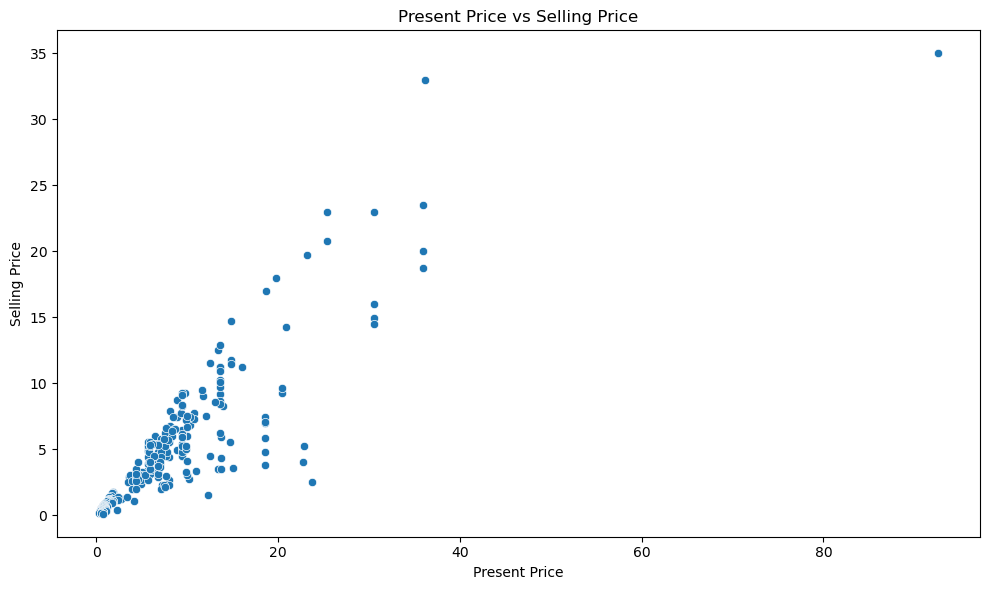

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df,
    x="Present_Price",
    y="Selling_Price")

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

## 12. Year vs Selling Price

The relationship between the manufacturing year and selling price
is examined.

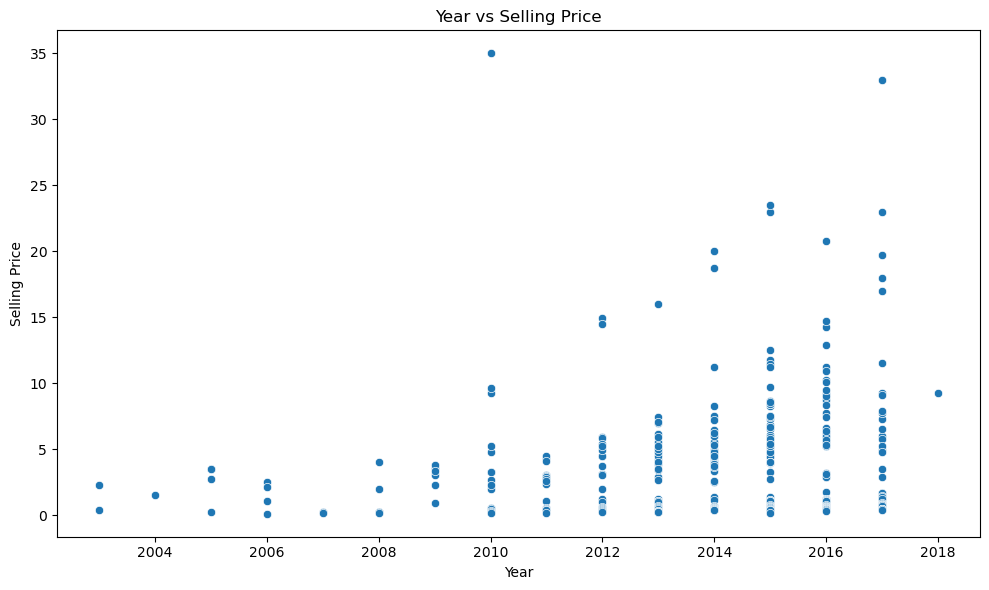

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df,
    x="Year",
    y="Selling_Price")

plt.title("Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

## 13. Kilometers Driven vs Selling Price

This analysis examines whether the number of kilometres driven
is associated with the selling price.

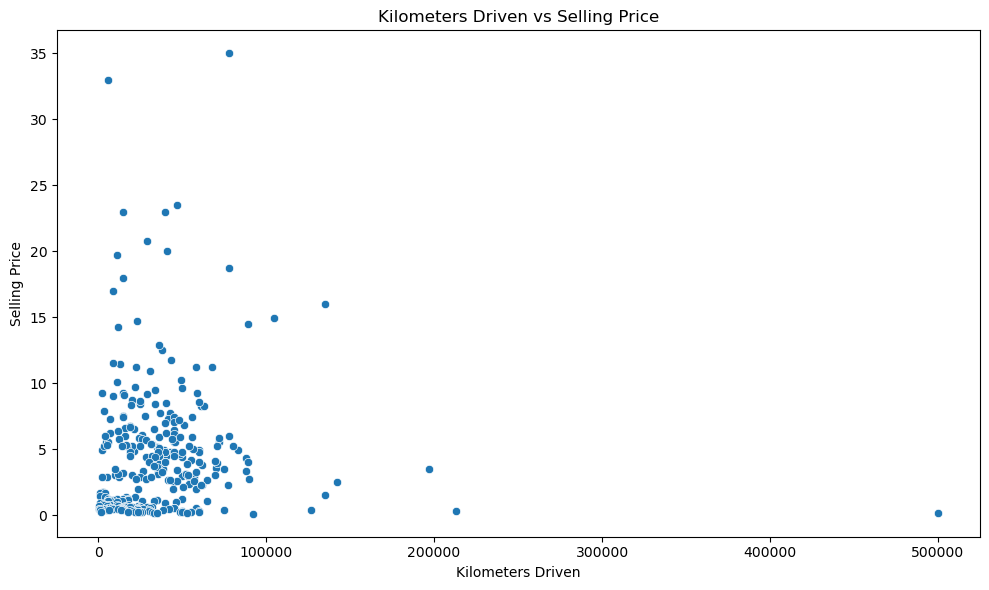

In [28]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df,
    x="Kms_Driven",
    y="Selling_Price")

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

## 14. Average Selling Price by Fuel Type

The average selling price is compared across different fuel types.

Average selling price by fuel type:
Fuel_Type
Diesel    10.102759
Petrol     3.264184
CNG        3.100000
Name: Selling_Price, dtype: float64


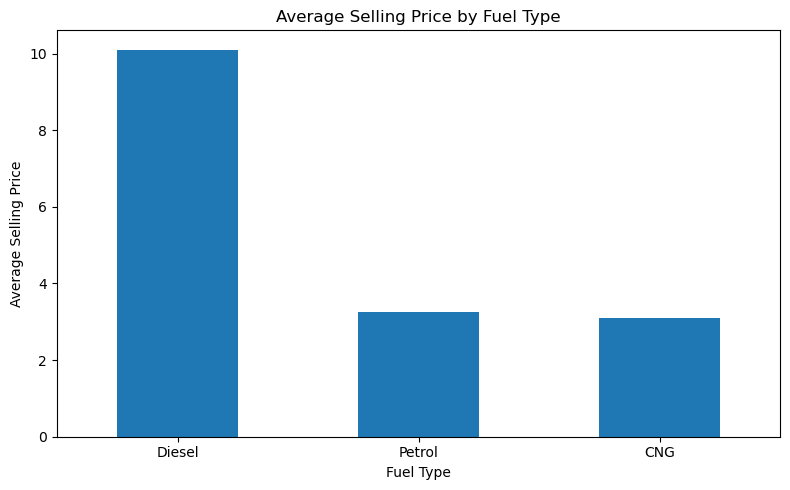

In [29]:
fuel_summary = (
    df.groupby("Fuel_Type")["Selling_Price"]
    .mean()
    .sort_values(ascending=False))

print("Average selling price by fuel type:")
print(fuel_summary)

plt.figure(figsize=(8, 5))

fuel_summary.plot(kind="bar")

plt.title("Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 15. Average Selling Price by Transmission

The average selling price is compared between different
transmission types.

Average selling price by transmission:
Transmission
Automatic    9.071795
Manual       3.917308
Name: Selling_Price, dtype: float64


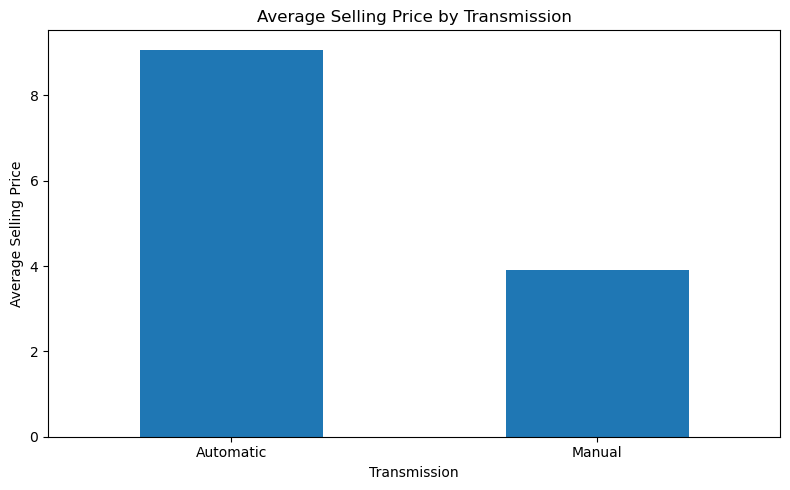

In [31]:
transmission_summary = (
    df.groupby("Transmission")["Selling_Price"]
    .mean()
    .sort_values(ascending=False))

print("Average selling price by transmission:")
print(transmission_summary)

plt.figure(figsize=(8, 5))

transmission_summary.plot(kind="bar")

plt.title("Average Selling Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Average Selling Price")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 16. Feature Engineering — Car Age

The manufacturing year is converted into a more useful feature called
`Car_Age`.

The latest year available in the dataset is used as the reference year.

In [34]:
latest_year = df["Year"].max()

df["Car_Age"] = latest_year - df["Year"]

print("Reference year:", latest_year)

df[["Year", "Car_Age"]].head()

Reference year: 2018


,Year,Car_Age
0,2014,4
1,2013,5
2,2017,1
3,2011,7
4,2014,4


## 17. Feature and Target Selection

The target variable is `Selling_Price`.

The remaining selected variables will be used as input features
for the machine learning models.

In [35]:
features = ["Present_Price","Kms_Driven","Fuel_Type","Seller_Type","Transmission","Owner","Car_Age"]

X = df[features]

y = df["Selling_Price"]

print("Features:")
print(features)

print("\nTarget:")
print("Selling_Price")

Features:
['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']

Target:
Selling_Price


## 18. Train-Test Split

The dataset is divided into training and testing data.

80% of the observations are used for training and 20% are used
for testing the machine learning models.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 239
Testing records: 60


## 19. Data Preprocessing

Categorical variables are converted into numerical values using
One-Hot Encoding.

In [38]:
categorical_features = ["Fuel_Type","Seller_Type","Transmission"]

numerical_features = ["Present_Price","Kms_Driven","Owner","Car_Age"]

preprocessor = ColumnTransformer(
    transformers=[("categorical",OneHotEncoder(handle_unknown="ignore"),categorical_features)],remainder="passthrough")

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 20. Linear Regression

Linear Regression is used as a baseline regression model for
predicting car selling prices.

In [39]:
linear_model = Pipeline([("preprocessor", preprocessor),("model", LinearRegression())])

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 21. Decision Tree Regression

A Decision Tree Regressor is used to model non-linear relationships
between the car features and selling price.

In [40]:
tree_model = Pipeline([("preprocessor", preprocessor),("model",DecisionTreeRegressor(max_depth=8,random_state=42))])

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## 22. Random Forest Regression

A Random Forest Regressor is trained using multiple decision trees.
This model is used to improve prediction performance and reduce
the effect of an individual tree.

In [41]:
forest_model = Pipeline([("preprocessor", preprocessor),("model",RandomForestRegressor(n_estimators=200,max_depth=10,random_state=42))])

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 23. Model Evaluation

The models are evaluated using:

- MAE — Mean Absolute Error
- MSE — Mean Squared Error
- RMSE — Root Mean Squared Error
- R² — Coefficient of Determination

Lower MAE, MSE and RMSE indicate lower prediction error.
A higher R² indicates better explanatory performance.

In [43]:
def evaluate_model(name, actual, predicted):
    
    mse = mean_squared_error(actual, predicted)
    
    return {"Model": name,"MAE": mean_absolute_error(actual, predicted),"MSE": mse,"RMSE": np.sqrt(mse),"R2": r2_score(actual, predicted)}


results_df = pd.DataFrame([evaluate_model("Linear Regression",y_test,linear_predictions),
    
    evaluate_model("Decision Tree",y_test,tree_predictions),
    
    evaluate_model("Random Forest",y_test,forest_predictions)])

results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,1.472892,6.370753,2.524035,0.752815
1,Decision Tree,1.081174,5.255266,2.292437,0.796096
2,Random Forest,1.461091,12.005832,3.464943,0.534175


## 25. Best Performing Model

The model with the highest R² score is selected as the best-performing
model for this analysis.

In [44]:
best_model_name = results_df.loc[
    results_df["R2"].idxmax(),
    "Model"]

if best_model_name == "Linear Regression":
    best_model = linear_model
    best_predictions = linear_predictions

elif best_model_name == "Decision Tree":
    best_model = tree_model
    best_predictions = tree_predictions

else:
    best_model = forest_model
    best_predictions = forest_predictions

print("Best model:", best_model_name)

Best model: Decision Tree


## 26. Actual vs Predicted Selling Price

The actual selling prices are compared with the predictions
generated by the best-performing model.

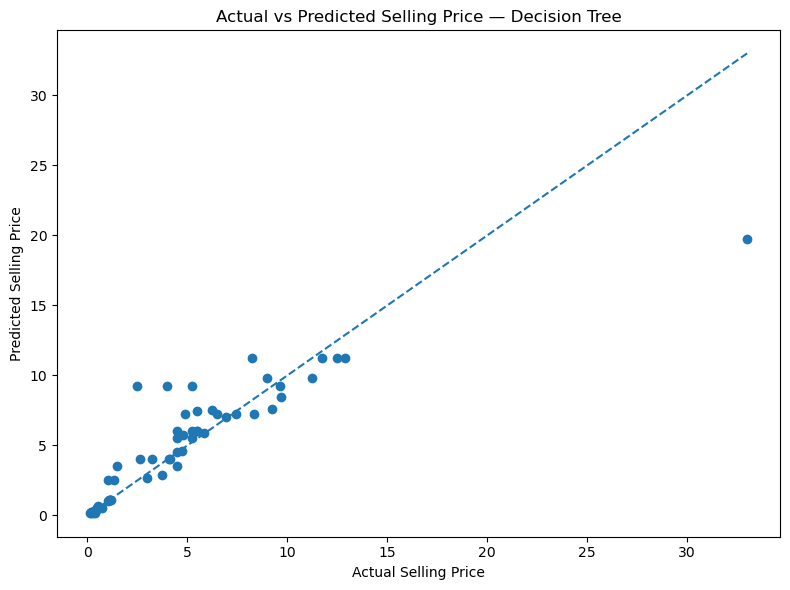

In [45]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test,best_predictions)

minimum = min(y_test.min(),best_predictions.min())

maximum = max(y_test.max(),best_predictions.max())

plt.plot([minimum, maximum],[minimum, maximum],linestyle="--")

plt.title(f"Actual vs Predicted Selling Price — {best_model_name}")

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.tight_layout()
plt.show()

## 27. Key Findings

Based on the analysis and model results, the following findings were observed:

1. Present price shows a clear positive relationship with selling price. Cars with higher present prices generally have higher selling prices.

2. Newer cars generally tend to have higher selling prices, although the relationship varies across individual vehicles.

3. Cars with higher kilometers driven generally tend to have lower selling prices, but the relationship is not very strong for all vehicles.

4. Diesel cars have the highest average selling price among the fuel types in this dataset, with an average of approximately 10.03.

5. Automatic cars have a higher average selling price than manual cars, with average selling prices of approximately 8.98 and 3.91 respectively.

6. Among the three machine learning models tested, Decision Tree Regression achieved the best performance.

7. The Decision Tree model achieved an R² score of approximately 0.796, with an MAE of 1.081 and an RMSE of 1.589.

8. Overall, the results show that factors such as present price, car age, kilometers driven, fuel type, seller type, transmission, and previous ownership can be useful for predicting used-car selling prices.

## 28. Conclusion

This project used Python and machine learning to predict the selling price of used cars.

The analysis included data cleaning, exploratory data analysis, feature engineering, categorical encoding, train-test splitting, and regression model evaluation.

Three models were tested: Linear Regression, Decision Tree Regression, and Random Forest Regression. Based on the evaluation results, Decision Tree Regression performed the best, achieving an R² score of approximately 0.796.

The results show that machine learning can be useful for estimating used-car prices based on available vehicle information. However, the predictions can still vary because used-car prices may also depend on other factors that are not included in the dataset.